# Структура обработанного датасета DRP-372 (только образцы 256x256x256)

## Папки

- data/npy/ - бинарные 3D-структуры пород (файлы *.npy)
- data/csv/ - целевые значения проницаемости (файлы *.csv)

## Формат .npy (входные данные)

- Размерность = (256, 256, 256)
- Тип данных: float32 (0 - поровое пространство, 1 - твёрдая фаза)
- Загрузка: `vol = np.load("data/npy/204_03_256.npy")`

## Формат .csv (целевые переменные)

Каждый CSV в data/csv/ содержит 6 строк (давления 1,2,5,10,20 МПа и LBM):

| pressure | permeability |
|----------|--------------|
| 1        |       |
| 2        |       |
| 5        |       |
| 10       |       |
| 20       |      |
| LBM      |     |

- pressure: давление в МПа (для LBM - строка 'LBM')
- permeability: проницаемость (при отсутствии данных - NaN)

Также все csv объединены в один файл с именем "dataset_combined.csv", расположенный в корне проекта

## PyTorch Dataset

Класс PermDataset возвращает пару (volume, target_vector):
- volume: тензор (1, 256, 256, 256)
- target: тензор (6,)

```python
dataset = PermDataset()
vol, perm = dataset[0]  # vol.shape=(1,256,256,256), perm.shape=(6,)

In [ ]:
# # @title Подгружаем библиотеки
# !pip install remotezip
# !pip install pyvista # Данная библиотека предоставляет инструменты для отрисовки 3-D моделей
# !pip install gudhi
# !pip install giotto-tda
# !pip install -U git+https://github.com/shizuo-kaji/CubicalRipser_3dim
# !pip install "numpy<2.0" "scikit-learn==1.3.2" ripser persim

In [3]:
# @title Подключаем библиотеки и настраиваем среду

# numpy
import numpy as np
print(f"Current NumPy version: {np.__version__}")
if np.__version__.startswith('2.'):
    print("\n[!] ВНИМАНИЕ: Нужно перезапустить сессию (Runtime -> Restart session), чтобы изменения вступили в силу.")

np.set_printoptions(precision=2, suppress=True, linewidth=120)

# gudhi
import gudhi as gd
from gudhi import bottleneck_distance
from gudhi.hera import wasserstein_distance
from gudhi.representations import BettiCurve, PersistenceImage, Landscape

# giotto
from gtda.homology import VietorisRipsPersistence
# from gtda.diagrams import BettiCurve, PersistenceImage, PersistenceLandscape
from gtda.homology import CubicalPersistence
from gtda.plotting import plot_diagram
from gtda.images import Binarizer, HeightFiltration, RadialFiltration, DensityFiltration, DilationFiltration, ErosionFiltration, SignedDistanceFiltration
import gtda.plotting as gtdaplot

# ripser & persim
from ripser import lower_star_img, Rips
from persim import plot_diagrams

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.datasets import make_circles

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
%matplotlib inline

# scipy
import scipy as sp
import scipy.stats as stats
from scipy.ndimage import zoom


import pyvista as pv
import scipy as sp
import pandas as pd
import os
import io
import h5py
import time
import gdown
import pickle
import fnmatch
import zipfile
import cripser
from remotezip import RemoteZip
from tqdm.notebook import tqdm
from IPython.display import Image, display


Current NumPy version: 1.26.4


# Подгрузка датасетов

## Получение и объединение .csv файлов с результатами симуляций, преобразование .mat -> .npy

In [4]:
# @title Код подгрузки данных первого датасета на случай потери доступа к гугл диску


# Код реорганизации данных
'''
url = "https://web.corral.tacc.utexas.edu/digitalporousmedia/archive/DRP-372/DRP-372_archive.zip"
os.makedirs("data/npy", exist_ok=True)
os.makedirs("data/csv", exist_ok=True)

def cb(name, obj):
  if isinstance(obj, h5py.Dataset) and obj.ndim == 3:
      return obj

def find_3d_dataset(h5_file):
  """Возвращает 3D массив или None."""
  ds = h5_file.visititems(cb)
  return ds

def get_permeability(csv_bytes):
  """Извлекает значение permeability из CSV."""
  try:
      text = csv_bytes.decode('utf-8')
      for line in text.splitlines():
          if 'permeability' in line.lower():
              parts = line.split(',')
              if len(parts) >= 2:
                  val = parts[1].strip()
                  if not val and len(parts) > 0:
                      val = parts[0].strip()
                  return float(val)
      return None
  except Exception as e:
      print(f"Ошибка парсинга: {e}")
      return None

with RemoteZip(url) as rz:
    all_files = rz.namelist()
    mat_files = [f for f in all_files if '_256.mat' in f and f.endswith('.mat')]

    for mat_path in tqdm(mat_files):
        name = mat_path.split('/')[-1][:-4]
        base_dir = '/'.join(mat_path.split('/')[:-1])

        #.mat -> .npy
        npy_path = f"data/npy/{name}.npy"
        if not os.path.exists(npy_path):
            try:
                rz.extract(mat_path, path='.')
                with h5py.File(mat_path, 'r') as hf:
                    vol = find_3d_dataset(hf)
                    if vol is not None:
                        np.save(npy_path, vol)
                os.remove(mat_path)
            except Exception as e:
                print(f"Ошибка при обработке {name}: {e}")
                continue

        # Поиск permeability
        perms = []
        pressures = [1,2,5,10,20,'LBM']
        for p in pressures:
            if p == 'LBM':
                pattern = f"{base_dir}/Single Phase*/LBM.csv"
            else:
                pattern = f"{base_dir}/Single Phase*/P_{p}_MPa.csv"
            matching = fnmatch.filter(all_files, pattern)
            if matching:
                csv_path = matching[0]
                try:
                    content = rz.read(csv_path)
                    perm = get_permeability(content)
                    perms.append(perm)
                except Exception as e:
                    print(f"Не удалось прочитать {csv_path}: {e}")
                    perms.append(None)
            else:
                perms.append(None)

        df_out = pd.DataFrame({'pressure': pressures, 'permeability': perms})
        df_out.to_csv(f"data/csv/{name}.csv", index=False)
        print(f"{name}: {perms}")
'''

'\nurl = "https://web.corral.tacc.utexas.edu/digitalporousmedia/archive/DRP-372/DRP-372_archive.zip"\nos.makedirs("data/npy", exist_ok=True)\nos.makedirs("data/csv", exist_ok=True)\n\ndef cb(name, obj):\n  if isinstance(obj, h5py.Dataset) and obj.ndim == 3:\n      return obj\n\ndef find_3d_dataset(h5_file):\n  """Возвращает 3D массив или None."""\n  ds = h5_file.visititems(cb)\n  return ds\n\ndef get_permeability(csv_bytes):\n  """Извлекает значение permeability из CSV."""\n  try:\n      text = csv_bytes.decode(\'utf-8\')\n      for line in text.splitlines():\n          if \'permeability\' in line.lower():\n              parts = line.split(\',\')\n              if len(parts) >= 2:\n                  val = parts[1].strip()\n                  if not val and len(parts) > 0:\n                      val = parts[0].strip()\n                  return float(val)\n      return None\n  except Exception as e:\n      print(f"Ошибка парсинга: {e}")\n      return None\n\nwith RemoteZip(url) as rz:\n  

In [5]:
# # @title Подгрузка первого датасета из гугл диска


# ZIP_URL = "https://drive.google.com/uc?export=download&id=1R40Kau_i1qEG3ge0by_sFncIXz7d0rCw"
# ZIP_PATH = "data.zip"
# EXTRACT_DIR = "data"

# if not os.path.exists(EXTRACT_DIR):
#     print("Скачивание архива с данными...")
#     gdown.download(ZIP_URL, ZIP_PATH, quiet=False)

#     print("Распаковка архива...")
#     with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
#         zip_ref.extractall(EXTRACT_DIR)

#     os.remove(ZIP_PATH)
#     print("Готово! Данные загружены в папку 'data'.")
# else:
#     print("Папка 'data' уже существует, пропускаем загрузку.")

In [6]:
# # @title Подгрузим файл с именами горных пород

# url = "https://docs.google.com/spreadsheets/d/1toagV4m4SN2T5RBMHSssU9RVSO4Zf9us/export?format=xlsx"
# output = "metadata.xlsx"
# gdown.download(url, output, quiet=False)

In [7]:
# # @title Подгрузка второго датасета (1000 вхождений), опционально

# FILE_ID = "1uDh0Vxdo-xHBgdAmI0h_DjFGDkMCKoVa"
# ZIP_PATH = "synthetic_data_256.zip"
# EXTRACT_DIR = "synthetic_data_extracted"

# def download_synthetic_zip():
#     if not os.path.exists(ZIP_PATH):
#         print("Скачиваем архив с Google Диска...")
#         gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)
#     else:
#         print("Архив уже скачан.")

# def extract_zip():
#     if not os.path.exists(EXTRACT_DIR):
#         print("Распаковываем архив...")
#         with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
#             zf.extractall(EXTRACT_DIR)
#     else:
#         print("Архив уже распакован.")

# download_synthetic_zip()
# extract_zip()

## Объединение .csv файлов в один и сохранение в корень

In [8]:
# @title Создание класса датасета, унаследованного от torch.utils.data.Dataset
def normalize_subsample(s):
    # Если float (NaN) или None, возвращаем пустую строку
    if not isinstance(s, str):
        return ''
    parts = s.split('_')
    norm = []
    for p in parts:
        try:
            norm.append(str(int(p)))
        except ValueError:
            norm.append(p)
    return '_'.join(norm)

def parse_name_for_rock_type(name):
    parts = name.split('_')
    if len(parts) < 3:
        return None, None
    try:
        sample = int(parts[0])
        sub_raw = '_'.join(parts[1:-1])
        sub_norm = normalize_subsample(sub_raw)
        return sample, sub_norm
    except ValueError:
        return None, None

class PermeabilityDataset(Dataset):
    def __init__(self, real_npy_dir='data/npy', real_csv_dir='data/csv',
                 metadata_path='metadata.xlsx',
                 synthetic_extract_dir='synthetic_data_extracted',
                 use_synthetic=True):
        self.real_npy_dir = real_npy_dir
        self.real_csv_dir = real_csv_dir
        self.synth_dir = synthetic_extract_dir
        self.use_synthetic = use_synthetic

        meta_df = pd.read_excel(metadata_path, sheet_name='Table_SI')
        meta_df = meta_df[['Sample', 'Subsample', 'Type']].copy()
        meta_df['Sample'] = meta_df['Sample'].ffill()
        meta_df.dropna(subset=['Sample'], inplace=True)
        meta_df['Sample'] = meta_df['Sample'].astype(int)
        meta_df['Subsample'] = meta_df['Subsample'].astype(str)

        self.meta_dict = {}
        self.fallback_dict = {}
        for _, row in meta_df.iterrows():
            sample = row['Sample']
            norm_sub = normalize_subsample(row['Subsample'])
            key = (sample, norm_sub)
            if key not in self.meta_dict:
                self.meta_dict[key] = row['Type']
            if sample not in self.fallback_dict:
                self.fallback_dict[sample] = row['Type']

        self.samples = []

        # Собираем реальные данные
        real_names = [f[:-4] for f in os.listdir(real_npy_dir) if f.endswith('.npy')]
        real_names = [s for s in real_names if os.path.exists(os.path.join(real_csv_dir, f"{s}.csv"))]

        # Числовая сортировка для корректного порядка (10_01_256, 16_01_256, 135_00_256...)
        def numerical_sort_key(name):
            parts = name.split('_')
            try:
                return [int(p) for p in parts if p.isdigit()]
            except ValueError:
                return name

        real_names.sort(key=numerical_sort_key)

        for idx, name in enumerate(real_names, start=1):
            self.samples.append({
                'type': 'real',
                'name': name,
                'ext_id': idx,   # внешний индекс
                'npy_path': os.path.join(real_npy_dir, f"{name}.npy"),
                'csv_path': os.path.join(real_csv_dir, f"{name}.csv")
            })

        if self.use_synthetic:
            synth_csv = os.path.join(self.synth_dir, 'synthetic_dataset.csv')
            synth_npy_dir = os.path.join(self.synth_dir, 'npy_256')
            if os.path.exists(synth_csv):
                df_synth = pd.read_csv(synth_csv)
                for _, row in df_synth.iterrows():
                    name = row['sample']
                    if name.endswith('.npy'):
                        name = name[:-4]
                    lbm_val = row['perm_LBM']
                    if pd.isna(lbm_val):
                        lbm_val = 0.0
                    self.samples.append({
                        'type': 'synth',
                        'name': name,
                        'ext_id': None,
                        'npy_path': os.path.join(synth_npy_dir, f"{name}.npy"),
                        'kappa': float(lbm_val)
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        if sample['type'] == 'real':
            return self._load_real(sample)
        else:
            return self._load_synthetic(sample)

    def _load_real(self, sample):
        vol = np.load(sample['npy_path'])
        vol = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

        df = pd.read_csv(sample['csv_path'])
        perm = df['permeability'].values.astype(np.float32)
        perm = np.nan_to_num(perm, nan=0.0)
        perm = torch.tensor(perm, dtype=torch.float32)

        return vol, perm, sample['name']

    def _load_synthetic(self, sample):
        vol = np.load(sample['npy_path'])
        vol = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

        kappa_m2 = sample['kappa'] * 1e-12
        perm = torch.full((6,), 0.0, dtype=torch.float32)
        perm[5] = kappa_m2

        return vol, perm, sample['name']

    def get_rock_type(self, name):
        for s in self.samples:
            if s['name'] == name:
                if s['type'] == 'real':
                    sample, sub_norm = parse_name_for_rock_type(name)
                    if sample is None:
                        return "unknown"
                    key = (sample, sub_norm)
                    if key in self.meta_dict:
                        return self.meta_dict[key]
                    return self.fallback_dict.get(sample, "unknown")
                else:
                    return name
        return "unknown"

    def get_name(self, idx):
        return self.samples[idx]['name']

    def remove_by_external_index(self, external_id):
        """Удаляет реальный образец по его внешнему индексу (как в dataset_combined.csv)."""
        idx_to_remove = None
        for i, s in enumerate(self.samples):
            if s['type'] == 'real' and s.get('ext_id') == external_id:
                idx_to_remove = i
                break
        if idx_to_remove is None:
            raise ValueError(f"Образец с внешним индексом {external_id} не найден среди реальных данных.")

        sample = self.samples[idx_to_remove]
        # Удаляем файлы
        for path in (sample['npy_path'], sample['csv_path']):
            if os.path.exists(path):
                os.remove(path)
        # Удаляем из списка
        self.samples.pop(idx_to_remove)
        print(f"Образец с внешним индексом {external_id} (имя '{sample['name']}') удалён.")

In [9]:
# @title Функция create_combined_file
def create_combined_file(metadata_path='metadata.xlsx'):
    csv_dir = "data/csv"
    output_file = "dataset_combined.csv"

    # Загружаем метаданные
    meta_df = pd.read_excel(metadata_path, sheet_name='Table_SI')
    meta_df = meta_df[['Sample', 'Subsample', 'Type']].copy()
    meta_df['Sample'] = meta_df['Sample'].ffill()
    meta_df.dropna(subset=['Sample'], inplace=True)
    meta_df['Sample'] = meta_df['Sample'].astype(int)
    meta_df['Subsample'] = meta_df['Subsample'].astype(str)

    meta_dict = {}
    fallback_dict = {}
    for _, row in meta_df.iterrows():
        sample = row['Sample']
        key = (sample, normalize_subsample(row['Subsample']))
        if key not in meta_dict:
            meta_dict[key] = row['Type']
        if sample not in fallback_dict:
            fallback_dict[sample] = row['Type']

    pressures = ['1', '2', '5', '10', '20', 'LBM']
    rows = []

    for idx, fname in enumerate(sorted(os.listdir(csv_dir)), start=1):
        if not fname.endswith('.csv'):
            continue
        name = fname[:-4]
        df = pd.read_csv(os.path.join(csv_dir, fname))
        df['pressure'] = df['pressure'].astype(str)
        perm_dict = dict(zip(df['pressure'], df['permeability']))
        perms = [perm_dict.get(p, None) for p in pressures]
        perms = [float(x) if x is not None else None for x in perms]

        # Определяем тип породы
        parts = name.split('_')
        if len(parts) >= 3:
            try:
                sample = int(parts[0])
                sub_raw = '_'.join(parts[1:-1])
                sub_norm = normalize_subsample(sub_raw)
                key = (sample, sub_norm)
                rock_type = meta_dict.get(key, fallback_dict.get(sample, "unknown"))
            except ValueError:
                rock_type = "unknown"
        else:
            rock_type = "unknown"

        rows.append([idx, name, rock_type] + perms)

    columns = ["index", "sample", "rock_type"] + [f"perm_{p}MPa" if p != 'LBM' else "perm_LBM" for p in pressures]
    pd.DataFrame(rows, columns=columns).to_csv(output_file, index=False)
    print(f"Сохранён {output_file} с {len(rows)} строками")



In [10]:
# @title
create_combined_file()
dataset = PermeabilityDataset()
print(f'перввый куб {dataset[0][2]}')
print(f'последний куб {dataset[-1][2]}')
print(f"Размер датасета: {len(dataset)}")
if len(dataset) > 0:
    sample_vol, sample_target, sample_name = dataset[0]
    print(f"Пример volume: {sample_vol}")
    print(f"Пример target: {sample_target}")
    print(f"Пример имени образца: {sample_name}")

Сохранён dataset_combined.csv с 125 строками
перввый куб 10_01_256
последний куб 374_10_03_256
Размер датасета: 125
Пример volume: tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         ...,

         [[1., 1., 1.,  ..., 1., 1., 1.],
     

## Предобработка данных. Работа с пропусками

In [11]:
# @title Найдём столбцы в которых есть пропуски и удалим сэмплы, о которых вообще нет данных


data_fix = pd.read_csv("dataset_combined.csv")

columns_of_interest = data_fix.columns[data_fix.isna().sum() > 0]
not_enough_data = data_fix[data_fix[columns_of_interest].isna().sum(axis=1) >= 5]
wrong_data = data_fix[data_fix[columns_of_interest].map(lambda x: True if x < 0 else False).sum(axis=1) >= 1]
data_fix.head(6)

,index,sample,rock_type,perm_1MPa,perm_2MPa,perm_5MPa,perm_10MPa,perm_20MPa,perm_LBM
0,1,10_01_256,Estaillades carbonate,0.245331,0.107933,0.050930,0.030250,0.017213,1.721331e-14
1,2,135_00_256,Leopard sandstone,0.000796,0.000388,0.000181,0.000095,0.000044,4.383886e-17
2,3,135_02_256,Leopard sandstone,0.234610,0.114866,0.043291,0.023835,0.012460,1.246048e-14
3,4,135_04_256,Leopard sandstone,0.080018,0.032333,0.013457,0.006849,0.003508,3.508229e-15
4,5,16_01_256,Poorly sorted unconsolidated fluvial sandpack,14.438577,6.939476,3.464192,2.136307,1.266970,1.266970e-12
5,6,16_02_256,Fossiliferous outcrop carbonate,40.821291,22.629270,13.651973,9.378623,6.449307,6.449307e-12


In [12]:
# @title
inappropriate_samples = pd.concat([not_enough_data, wrong_data])
print(inappropriate_samples)
print(len(data_fix))
for ext_id in inappropriate_samples['index']:
    try:
        dataset.remove_by_external_index(ext_id)
    except ValueError as e:
        print(f"Ошибка при удалении внешнего индекса {ext_id}: {e}")
create_combined_file()

     index         sample                                 rock_type  \
17      18     204_06_256                    Bidispersed spherepack   
22      23     207_02_256                         Vaca Muerta shale   
43      44     344_03_256                     Estaillades carbonate   
54      55  374_01_08_256                        Dilated spherepack   
121    122      69_01_256  Statistically reconstructed thin section   
123    124      72_02_256                     Savonnières carbonate   
25      26     297_01_256              Belgian fieldstone sandstone   

     perm_1MPa    perm_2MPa  perm_5MPa  perm_10MPa  perm_20MPa      perm_LBM  
17         NaN          NaN        NaN         NaN         NaN           NaN  
22         NaN          NaN        NaN         NaN         NaN           NaN  
43         NaN          NaN        NaN         NaN         NaN           NaN  
54         NaN          NaN        NaN         NaN         NaN           NaN  
121        NaN          NaN        N

Теперь нужно понять, как заменить пропущенные значения для лучшего последующего обучения

### Гипотеза: существует линейная зависимость между давлением в мПа и значением проницаемости породы

In [13]:
# @title Проверим с помощью стат критерия на основе корреляции Пирсона


df = pd.read_csv('dataset_combined.csv')

pressure_cols = ['perm_1MPa', 'perm_2MPa', 'perm_5MPa', 'perm_10MPa', 'perm_20MPa']
pressure_values = np.array([1.0, 2.0, 5.0, 10.0, 20.0])

results_list = []

for idx, row in df.iterrows():
    sample_id = row['sample']

    perms = np.array([row[col] for col in pressure_cols], dtype=float)
    mask = ~np.isnan(perms)
    n_points = mask.sum()

    if n_points < 2:
        results_list.append({
            'sample': sample_id,
            'n_points': n_points,
            'pearson_r': np.nan,
            'p_value': np.nan,
            'is_significant': False
        })
        continue

    p_vals = pressure_values[mask]
    k_vals = perms[mask]

    r, p = stats.pearsonr(p_vals, k_vals)

    results_list.append({
        'sample': sample_id,
        'n_points': n_points,
        'pearson_r': r,
        'p_value': p,
        'is_significant': p < 0.05
    })

results = pd.DataFrame(results_list)

print("=" * 60)
print("РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА (ПИРСОН)")
print("=" * 60)
print(f"Всего образцов: {len(results)}")

valid = results[results['n_points'] >= 2]
print(f"Образцов с >=2 точками: {len(valid)}")
print(f"Из них со значимой корреляцией: {valid['is_significant'].sum()}")
print(f"Доля значимых: {valid['is_significant'].mean():.2%}")

print("\nРаспределение коэффициента Пирсона (r):")
print(valid['pearson_r'].describe())


РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА (ПИРСОН)
Всего образцов: 118
Образцов с >=2 точками: 111
Из них со значимой корреляцией: 0
Доля значимых: 0.00%

Распределение коэффициента Пирсона (r):
count    111.000000
mean      -0.723866
std        0.109846
min       -0.803984
25%       -0.745845
50%       -0.732143
75%       -0.717202
max        0.402913
Name: pearson_r, dtype: float64


Видим, что линейной зависимости нет, но прослеживается существование некоторого закона изменения проницаемости в зависимости от приложенного давления

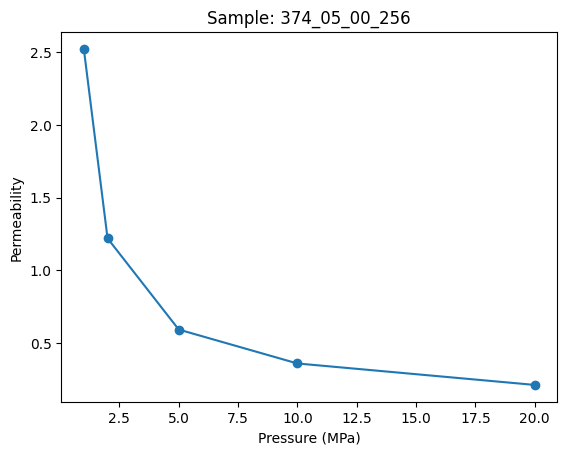

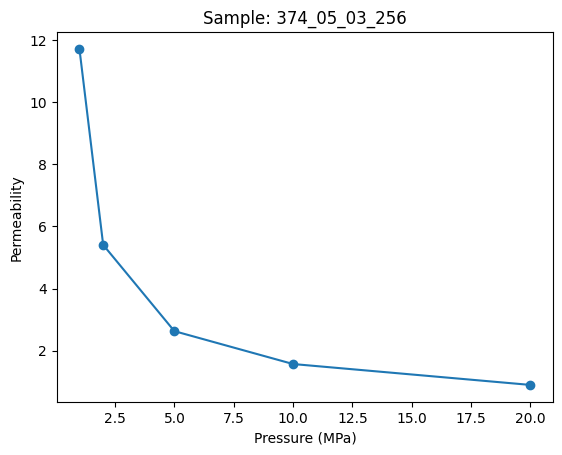

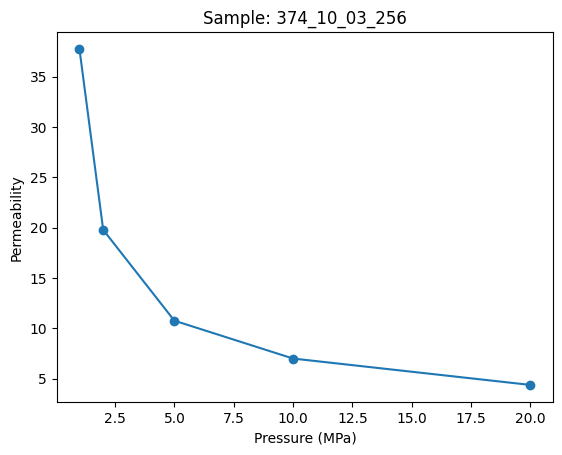

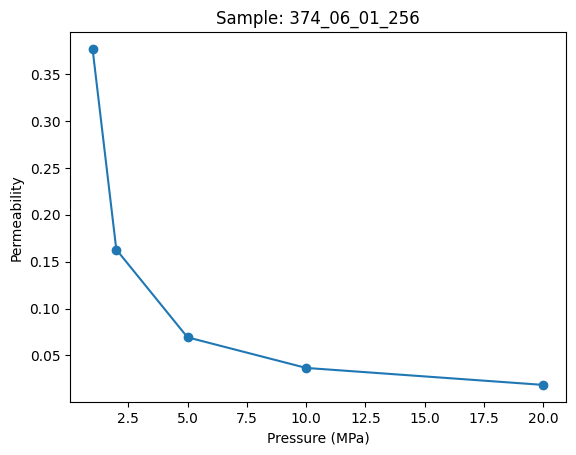

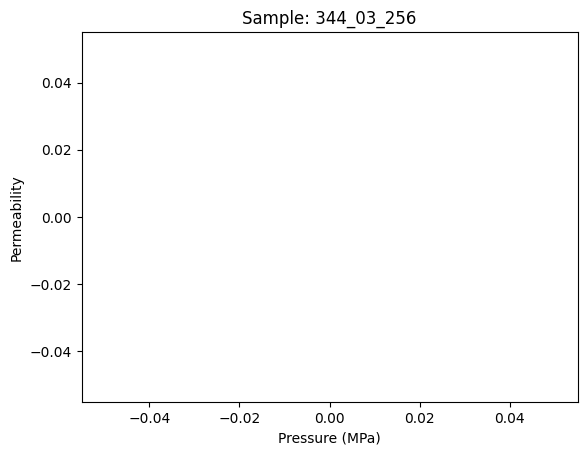

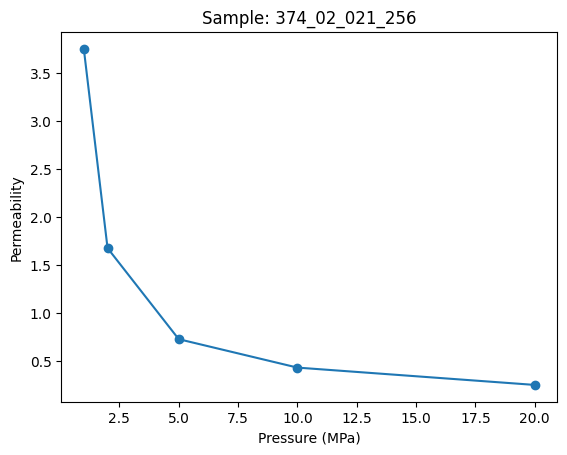

In [14]:
# @title
import matplotlib.pyplot as plt

for _, i in df.sample(6).iterrows():
  perms = i[pressure_cols].values.astype(float)
  plt.plot(pressure_values, perms, 'o-')
  plt.title(f"Sample: {i['sample']}")
  plt.xlabel("Pressure (MPa)")
  plt.ylabel("Permeability")
  plt.show()

In [15]:
# @title Заполним наны благодаря такой зависимости

def fill_permeability_gaps(df, visualize=True, n_plots=4, random_state=42, fill_lbm=True, lbm_factor=1e-12):

    pressures = np.array([1, 2, 5, 10, 20], dtype=float)
    perm_cols = [f'perm_{int(p)}MPa' for p in pressures]

    df_filled = df.copy()
    samples_with_fills = []

    def power_law(P, a, b):
        return a * np.power(P, b)

    for idx, row in df_filled.iterrows():
        values = pd.to_numeric(row[perm_cols], errors='coerce').to_numpy(dtype=float)
        valid_mask = ~np.isnan(values)
        P_valid = pressures[valid_mask]
        k_valid = values[valid_mask]

        if len(P_valid) < 2:
            continue
        if np.any(k_valid <= 0):
            continue

        try:
            logP = np.log(P_valid)
            logK = np.log(k_valid)
            coeffs = np.polyfit(logP, logK, 1)
            b = coeffs[0]
            a = np.exp(coeffs[1])
            k_pred = power_law(pressures, a, b)

            had_fill = False
            for i, col in enumerate(perm_cols):
                if pd.isna(row[col]):
                    df_filled.at[idx, col] = k_pred[i]
                    had_fill = True
            if had_fill:
                samples_with_fills.append(idx)
        except Exception as e:
            continue

    if fill_lbm and 'perm_LBM' in df_filled.columns:
        for idx, row in df_filled.iterrows():
            if pd.isna(row['perm_LBM']):
                perm_20 = df_filled.at[idx, 'perm_20MPa']
                if not pd.isna(perm_20):
                    df_filled.at[idx, 'perm_LBM'] = perm_20 * lbm_factor
                else:
                    pass

    if visualize and samples_with_fills:
        np.random.seed(random_state)
        selected = np.random.choice(samples_with_fills,
                                    size=min(n_plots, len(samples_with_fills)),
                                    replace=False)

        for idx in selected:
            row_original = df.loc[idx]
            row_filled = df_filled.loc[idx]

            orig_vals = pd.to_numeric(row_original[perm_cols], errors='coerce').to_numpy(dtype=float)
            mask_known = ~np.isnan(orig_vals)
            P_known = pressures[mask_known]
            k_known = orig_vals[mask_known]

            filled_vals = row_filled[perm_cols].to_numpy(dtype=float)
            mask_filled = np.isnan(orig_vals)
            P_filled = pressures[mask_filled]
            k_filled = filled_vals[mask_filled]

            P_smooth = np.linspace(1, 20, 100)
            logP_known = np.log(P_known)
            logK_known = np.log(k_known)
            coeffs = np.polyfit(logP_known, logK_known, 1)
            a = np.exp(coeffs[1])
            b = coeffs[0]
            k_smooth = power_law(P_smooth, a, b)

            plt.figure(figsize=(10, 5))
            plt.plot(P_smooth, k_smooth, '--', color='gray', alpha=0.8, label='Степенная модель')
            plt.plot(P_known, k_known, 'o', color='blue', markersize=8, label='Исходные данные')
            plt.plot(P_filled, k_filled, 's', color='red', markersize=8, label='Заполненные значения')
            plt.title(f"Образец: {row_original['sample']}\n")
            plt.xlabel("Эффективное давление, МПа")
            plt.ylabel("Проницаемость (единицы исходных данных)")
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.legend()

    print(f"Обработано образцов: {len(df)}. Заполнены пропуски в {len(samples_with_fills)} образцах.")
    return df_filled

filled_df = fill_permeability_gaps(df)


Обработано образцов: 118. Заполнены пропуски в 0 образцах.


Пропуски заполнены, обновим датасет

In [16]:
filled_df.isna().sum()

index         0
sample        0
rock_type     0
perm_1MPa     7
perm_2MPa     7
perm_5MPa     7
perm_10MPa    7
perm_20MPa    6
perm_LBM      6
dtype: int64

In [17]:
# @title

filled_df.to_csv("dataset_combined.csv", index=False)
print(f"Обновлённый файл dataset_combined.csv сохранён.")

csv_dir = "data/csv"
pressures = ['1', '2', '5', '10', '20', 'LBM']
col_map = {
    '1': 'perm_1MPa',
    '2': 'perm_2MPa',
    '5': 'perm_5MPa',
    '10': 'perm_10MPa',
    '20': 'perm_20MPa',
    'LBM': 'perm_LBM'
}

for _, row in filled_df.iterrows():
    sample_name = row['sample']
    csv_file = os.path.join(csv_dir, f"{sample_name}.csv")

    data = []
    for p in pressures:
        col = col_map[p]
        if col in row.index:
            val = row[col]
            if pd.notna(val):
                data.append({'pressure': p, 'permeability': val})

    if data:
        sample_df = pd.DataFrame(data)
        sample_df.to_csv(csv_file, index=False)
        print(f"Обновлён: {csv_file}")
    else:
        print(f"Пропущен (нет данных): {sample_name}")

print("Все файлы обновлены.")

dataset = PermeabilityDataset()


Обновлённый файл dataset_combined.csv сохранён.
Обновлён: data/csv/10_01_256.csv
Обновлён: data/csv/135_02_256.csv
Обновлён: data/csv/135_04_256.csv
Обновлён: data/csv/16_01_256.csv
Обновлён: data/csv/16_02_256.csv
Обновлён: data/csv/172_02_256.csv
Обновлён: data/csv/172_03_256.csv
Обновлён: data/csv/204_010_256.csv
Обновлён: data/csv/204_011_256.csv
Обновлён: data/csv/204_012_256.csv
Обновлён: data/csv/204_01_256.csv
Обновлён: data/csv/204_02_256.csv
Обновлён: data/csv/204_03_256.csv
Обновлён: data/csv/204_04_256.csv
Обновлён: data/csv/204_05_256.csv
Пропущен (нет данных): 204_06_256
Обновлён: data/csv/204_07_256.csv
Обновлён: data/csv/204_08_256.csv
Обновлён: data/csv/204_09_256.csv
Обновлён: data/csv/207_01_256.csv
Пропущен (нет данных): 207_02_256
Обновлён: data/csv/207_04_256.csv
Обновлён: data/csv/297_01_256.csv
Обновлён: data/csv/317_010_256.csv
Обновлён: data/csv/317_01_256.csv
Обновлён: data/csv/317_02_256.csv
Обновлён: data/csv/317_03_256.csv
Обновлён: data/csv/317_04_256.csv

In [18]:
dataset[124]

IndexError: list index out of range

# Фильтрация бинарных рисунков
Фнкции фильтрации позволяют покрасить пустоты в
 градиент, что в дальнейшем позволит делать градацию серого и считать персистентные гомологии.

## Функция визуализации породы
Данная функция позволяет отрисовать изображение породы по трехмерному бинарному массиву данных

In [19]:
# @title visualize

def visualize(data, sample_name='rock_structure_1', substance_name = "rock_1",
              L = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, decimation_factor=0.9, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape

    # Создаем сетку
    grid = pv.ImageData(dimensions=shape, spacing=(1, 1, 1), origin=(0, 0, 0))
    grid.point_data["values"] = data_np.flatten(order="F")

    # Генерация изоповерхности (максимальное количество полигонов на входе)
    surface_mesh = grid.contour([0.5], scalars="values")

    # Агрессивное уменьшение количества полигонов (Decimation)
    if decimation_factor > 0 and surface_mesh.n_cells > 0:
        surface_mesh = surface_mesh.decimate(decimation_factor)

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Рисуем границы куба
    plotter.add_mesh(surface_mesh, color='grey', lighting=True) ## smooth_shading=True добавлять?
    plotter.add_mesh(pv.Cube(bounds=[0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1]),
                     style='wireframe', color='black', line_width=1, opacity=0.5) # добавляем границы

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L
    plotter.add_title(substance_name, font_size=10)  # название камня

    img_path = f'/tmp/{sample_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del surface_mesh
    del grid

    if T:
      display(Image(img_path))

In [20]:
# @title visualize_color_rock, _pore, _all, _binary

def visualize_color_rock(data, filtration_vol, file_name='rock_structure_colored',
                         L = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, decimation_factor=0.9, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Записываем маску породы и значения фильтрации в данные ячеек (cell_data)
    grid.cell_data["rock_mask"] = data_np.flatten(order="F").astype(np.uint8)
    grid.cell_data["dist_value"] = filt_np.flatten(order="F")

    # Переносим данные из ячеек в точки (point_data), так как алгоритм contour работает с точками
    grid = grid.cell_data_to_point_data()

    # Создаем полигональную сетку (изоповерхность) на границе пора/порода (значение 0.5)
    mesh = grid.contour([0.5], scalars="rock_mask")

    # Уменьшаем количество полигонов для ускорения отрисовки, если задан коэффициент
    if decimation_factor > 0 and mesh.n_cells > 0:
        mesh = mesh.decimate(decimation_factor)

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Добавляем сетку в визуализатор, раскрашивая по значениям фильтрации, убираем шкалу
    if "dist_value" in mesh.point_data:
        plotter.add_mesh(mesh, scalars="dist_value", cmap="jet", lighting=True, show_scalar_bar=False)
    else:
        # Если данные потерялись при децимации, интерполируем их заново
        mesh = mesh.sample(grid)
        plotter.add_mesh(mesh, scalars="dist_value", cmap="jet", lighting=True, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(pv.Cube(bounds=[0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1]),
                     style='wireframe', color='black', opacity=0.5)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del mesh
    del grid

    if T:
      display(Image(img_path))


def visualize_color_pore(data, filtration_vol, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Если порода (data == 0), присваиваем -0.1 для серого цвета
    vis_values = np.where(data_np == 1, filt_np, -0.1)
    grid.cell_data["colors"] = vis_values.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    # Создаем модифицированный jet
    jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
    new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
    custom_cmap = LinearSegmentedColormap.from_list('jet_with_grey', new_colors)

    plotter.add_mesh(faces, scalars="colors", cmap=custom_cmap,
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def visualize_color_all(filtration_vol, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)
    shape = filt_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))


    grid.cell_data["colors"] = filt_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    plotter.add_mesh(faces, scalars="colors", cmap='jet',
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def visualize_color_binary(data, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Если порода (data == 0), присваиваем -0.1 для серого цвета
    grid.cell_data["colors"] = data_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')


    plotter.add_mesh(faces, scalars="colors", cmap=ListedColormap(['#6a6863', 'white']),
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))

In [21]:
# @title Функции отрисовки срезов
def show_slice(data, k=128, axis = 'z', T = True):
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = data.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = data.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = data.squeeze()[:, :, k]

    if not T:
      return slice_2d

    # Визуализация среза
    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=ListedColormap(['#6a6863', 'white'])) #  0-серый (порода), 1-белый (поры)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_pore(data, normalized_grad, k=128, axis = 'z', T = True):
    # Применяем маску: там где порода (data == 0), ставим -0.1 для серого цвета
    vis_volume = np.where(data.squeeze() == 1, normalized_grad.squeeze(), -0.1)

    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d


    # Создаем копию jet, но добавляем цвет #6a6863 для породы
    jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
    new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
    custom_cmap = LinearSegmentedColormap.from_list('custom_jet', new_colors)

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=custom_cmap)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_rock(data, normalized_grad, k=128, axis = 'z', T = True):
    # Применяем маску: там где поры (data == 1), ставим -0.1 для белого цвета
    vis_volume = np.where(data.squeeze() == 0, normalized_grad.squeeze(), -0.1)

    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d

    # Создаем копию jet, но для пор устанавливаем белый цвет
    base_cmap = plt.get_cmap('jet')
    new_colors = base_cmap(np.linspace(0, 1, 256))
    custom_cmap = LinearSegmentedColormap.from_list('custom_jet_rock', new_colors)
    custom_cmap.set_under('white')

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=custom_cmap)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_all(normalized_grad, k=128, axis = 'z', T = True):
    vis_volume = normalized_grad.squeeze()
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap='jet')
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()

In [22]:
# @title show_filtration, show_filtration_small

def show_filtration(data, filt, sample_name='rock_1', substance_name = "rock_1", axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    # Предварительная генерация 3D скриншотов
    data=data.squeeze()
    filt=filt.squeeze()
    visualize(data, sample_name, substance_name, camera_position, False)
    visualize_color_rock(data, filt, f'rock_{sample_name}', camera_position, False)
    visualize_color_pore(data, filt, f'pore_{sample_name}', camera_position, False)

    # Создаем общую фигуру 4x3
    fig = plt.figure(figsize=(18, 24))

    # заголовок
    fig.text(0.15, 0.91, f"Образец: {sample_name}", fontsize=20, va='center')

    # шкала min max
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig.add_axes([0.42, 0.90, 0.53, 0.015])
    cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
    cb.set_label('Filtration values', labelpad=-75, fontsize=18)
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['min', 'max'], fontsize=18)

    # 3D визуализация
    paths = [f'/tmp/{sample_name}.png', f'/tmp/rock_{sample_name}.png', f'/tmp/pore_{sample_name}.png']
    for i, path in enumerate(paths):
        ax = fig.add_subplot(4, 3, i + 1)
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.axis('off')


    for i, k in enumerate(levels):
        row_idx = i + 1

        # Колонка 1: show_slice
        ax_bin = fig.add_subplot(4, 3, row_idx * 3 + 1)
        ax_bin.imshow(data[:, k, :] if axis == 'z' else (data[k, :, :] if axis == 'x' else data[:, :, k]), cmap=ListedColormap(['#6a6863', 'white']))
        ax_bin.axis('off')
        ax_bin.text(-0.05, 0.5, f"{axis} = {k}", transform=ax_bin.transAxes,
                    rotation='vertical', va='center', ha='right', fontsize=16)

        # Колонка 2: show_slice_filtered_rock
        ax_rock = fig.add_subplot(4, 3, row_idx * 3 + 2)
        ax_rock.imshow(filt[:, k, :] if axis == 'z' else (filt[k, :, :] if axis == 'x' else filt[:, :, k]), cmap='jet')
        ax_rock.axis('off')

        # Колонка 3: show_slice_filtered_pore
        ax_pore = fig.add_subplot(4, 3, row_idx * 3 + 3)
        vis_pore = np.where(data == 1, filt, -0.1)
        jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
        new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
        custom_cmap = LinearSegmentedColormap.from_list('custom_jet', new_colors)
        ax_pore.imshow(vis_pore[:, k, :] if axis == 'z' else (vis_pore[k, :, :] if axis == 'x' else vis_pore[:, :, k]), cmap=custom_cmap)
        ax_pore.axis('off')

    # Настраиваем отступы вручную, чтобы убрать пустоту справа
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.05, wspace=0.05, hspace=0.1)
    plt.show()


def show_filtration_small(filt, sample_name='rock_1', substance_name = "rock_1", axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    # Предварительная генерация 3D скриншотов
    filt=filt.squeeze()

    visualize_color_all(filt, f'all_{sample_name}', camera_position, False)

    # Создаем общую фигуру
    fig, ax = plt.subplots(nrows=1, ncols=1 + len(levels), figsize=(10 + len(levels), 18))
    #fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)



    img_all = mpimg.imread(f'/tmp/all_{sample_name}.png')
    ax[0].imshow(img_all)
    ax[0].set_title(f'{substance_name} \n {sample_name}' )
    ax[0].axis('off')

    for i, k in enumerate(levels):
        ax_idx = i + 1
        # Показываем срезы на оставшихся осях
        slice_img = filt[:, k, :] if axis == 'z' else (filt[k, :, :] if axis == 'x' else filt[:, :, k])
        ax[ax_idx].imshow(slice_img, cmap='jet')
        ax[ax_idx].set_title(f"{axis}={k}")
        ax[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

## Общие параметры

In [23]:
# # @title

# n = 1
# vol_tensor, target, sample_name = dataset[n]
# data = 1 - vol_tensor.squeeze().numpy().astype(np.uint8)



# print(f'Имя файла {sample_name}, размер {data.shape}')
# print(f'Пористость породы {int(np.sum(data)) / 256**3}') # 1 - поры, 0 - породы
# print(target)
# visualize(data, sample_name, dataset.get_rock_type(sample_name))

## Функции фильтраций

In [24]:
# @title Height filtration

def apply_height_filtration(data, normal=(0, 0, 1), d=0):
    L = []
    for i in data:
        L.append(apply_height_filtration_one(i, normal, d))
    return np.array(L)


def apply_height_filtration_one(data, normal=(0, 0, 1), d=0):
    shape = data.shape
    # Создаем сетку координат, центрированную относительно центра куба
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    z_c, y_c, x_c = z - (shape[0] // 2 - 1), y - (shape[0] // 2 - 1), x - (shape[0] // 2 - 1)

    # Нормируем вектор нормали
    n = np.array(normal) / np.linalg.norm(normal)

    # Вычисляем расстояние от каждой точки до плоскости
    dist_from_plane = x_c * n[0] + y_c * n[1] + z_c * n[2] - d
    filtration_values = np.abs(dist_from_plane)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)

    return filtration_values


In [63]:
#@title Radial filtration
def apply_radial_filtration(data, p=None):
    L = []
    for i in data:
        L.append(apply_radial_filtration_one(i, p))
    return np.array(L)

def apply_radial_filtration_one(data, p=None):
    shape = data.shape

    if p is None:
        p = (shape[0]//2, shape[1]//2, shape[2]//2)

    # Создаем сетку координат
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]

    # Вычисляем квадраты расстояний от центра p для каждой оси
    dist_sq = (x - p[0])**2 + (y - p[1])**2 + (z - p[2])**2
    filtration_values = np.sqrt(dist_sq)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)

    return filtration_values

In [26]:
# @title Line filtration (New)

def apply_line_filtration(data, p1=(0, 0, 0), p2=(255, 255, 255)):
    L = []
    for i in data:
        L.append(apply_line_filtration_one(i, p1, p2))
    return np.array(L)


def apply_line_filtration_one(data, p1=(0, 0, 0), p2=(255, 255, 255)):
    shape = data.shape
    # Создаем сетку координат
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    p1 = np.array(p1)
    p2 = np.array(p2)

    # Векторы от p1 до всех точек сетки
    dx, dy, dz = x - p1[0], y - p1[1], z - p1[2]

    # Направляющий вектор прямой (p2 - p1) и его норма
    v = p2 - p1
    v_norm_sq = np.sum(v**2) + 1e-9

    # Расстояние от точки до прямой
    cross_x = dy * v[2] - dz * v[1]
    cross_y = dz * v[0] - dx * v[2]
    cross_z = dx * v[1] - dy * v[0]

    filtration_values = np.sqrt((cross_x**2 + cross_y**2 + cross_z**2) / v_norm_sq)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)


    return filtration_values

In [29]:
# @title Функции фильтраций из библиотеки giotto-tda и подключение кастомных

#HeightFiltration
HF = HeightFiltration(direction=np.array([0, 1, 1])) # [z, x, y]
height_filt_gt= HF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#RadialFiltration
RF = RadialFiltration(np.array([127, 127, 127])) # [z, x, y]
radial_filt_gt = RF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#DensityFiltration
DeF = DensityFiltration()
density_filt_gt= DeF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#DilationFiltration
DiF = DilationFiltration()
dilation_filt_gt= DiF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#ErosionFiltration
EF = ErosionFiltration()
erosion_filt_gt= EF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#SignedDistanceFiltration
SDF = SignedDistanceFiltration()
signed_distence_filt_gt = SDF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


# Кастомные фильтрации
height_filt = apply_height_filtration(data[np.newaxis, :, :, :], normal=(1, 1, 1), d=100).astype(np.float32)
line_filt = apply_line_filtration(data[np.newaxis, :, :, :], (127, 127, 127), (255, 255, 255)).astype(np.float32)

TypeError: list indices must be integers or slices, not tuple

In [28]:
# # @title Визуализация фильтраций

# print(f"Форма входных данных: {data[np.newaxis, :, :, :].shape}")


# fig, ax = plt.subplots(ncols=2, figsize=(10, 10))

# visualize(data, sample_name, dataset.get_rock_type(sample_name), L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T=False)
# visualize_color_binary(data, f'binary_{sample_name}', [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], False)

# img = mpimg.imread(f'/tmp/{sample_name}.png')
# ax[0].imshow(img)
# ax[0].axis('off')

# img_bin = mpimg.imread(f'/tmp/binary_{sample_name}.png')
# ax[1].imshow(img_bin)
# ax[1].axis('off')

# plt.show()

# # Отображаем результат
# print("Height Filtration giotto-tda")
# print(f'min: {height_filt_gt.min()}, max: {height_filt_gt.max()}')
# show_filtration_small(height_filt_gt, f"{sample_name}_height_gt", dataset.get_rock_type(sample_name))

# print("Radial Filtration giotto-tda")
# print(f'min: {radial_filt_gt.min()}, max: {radial_filt_gt.max()}')
# show_filtration_small(radial_filt_gt, f"{sample_name}_radial_gt", dataset.get_rock_type(sample_name))

# print("Density Filtration giotto-tda")
# print(f'min: {density_filt_gt.min()}, max: {density_filt_gt.max()}')
# show_filtration_small(density_filt_gt, f"{sample_name}_density_gt", dataset.get_rock_type(sample_name))

# print("Dilation Filtration giotto-tda")
# print(f'min: {dilation_filt_gt.min()}, max: {dilation_filt_gt.max()}')
# show_filtration_small(dilation_filt_gt, f"{sample_name}_dilation_gt", dataset.get_rock_type(sample_name))

# print("Erosion Filtration giotto-tda")
# print(f'min: {erosion_filt_gt.min()}, max: {erosion_filt_gt.max()}')
# show_filtration_small(erosion_filt_gt, f"{sample_name}_erosion_gt", dataset.get_rock_type(sample_name))

# print("Signed Distence Filtration giotto-tda")
# print(f'min: {signed_distence_filt_gt.min()}, max: {signed_distence_filt_gt.max()}')
# show_filtration_small(signed_distence_filt_gt, f"{sample_name}_signed_distence_gt", dataset.get_rock_type(sample_name))

# # Визуализация кастомных фильтраций
# print("Height Filtration custom")
# print(f'min: {height_filt.min()}, max: {height_filt.max()}')
# show_filtration_small(height_filt, f"{sample_name}_height", dataset.get_rock_type(sample_name))

# print("Line Filtration custom")
# print(f'min: {line_filt.min()}, max: {line_filt.max()}')
# show_filtration_small(line_filt, f"{sample_name}_line", dataset.get_rock_type(sample_name))


In [30]:
# show_filtration(data, line_filt, sample_name, dataset.get_rock_type(sample_name))

# Подсчёт персистентных диаграмм и визуализация кубического комплекса
В этом разделе мы считаем персистентные диаграммы при помощи методов библиотеки GUDHI для уже отфильтрованных в предыдущем разделе массивов, а также визуализуруем кибические комплексы разными способами.

## Визуализация в сером

In [31]:
# @title Функции визуализации grayscale

def show_slice_grayscale(grad_data, k=40, axis = 'z', T = True):
    if axis == 'z':
      # Извлекаем срез по оси z
      grayscale_2d = grad_data.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      grayscale_2d = grad_data.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      grayscale_2d = grad_data.squeeze()[:, :, k]

    if not T:
      return grayscale_2d

    plt.figure(figsize=(8, 8))
    plt.imshow(grayscale_2d, cmap='gray') # gray 0 -> черный, 1 -> белый
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def visualize_grayscale_faces(grad_data, sample_name='grayscale_pore_cube_faces',
                         camera_position=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    grad_data_np = np.flip(grad_data.squeeze(), axis=0)
    shape = grad_data_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Добавляем данные в сетку
    grid.cell_data["colors"] = grad_data_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    # Теперь массив 'colors' существует в данных поверхности
    plotter.add_mesh(faces, scalars="colors", cmap='gray',
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = camera_position

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{sample_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def show_grayscale_small(grayscale_filt, sample_name='rock_1', substance_name = "rock_1", filt_name = 'filtration_name', axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    grayscale_filt=grayscale_filt.squeeze()
    visualize_grayscale_faces(grayscale_filt, f'multipl_{small_sample_name}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)


    fig, ax = plt.subplots(ncols= 1 + len(levels), figsize=(10 + len(levels), 18))

    ax[0].imshow(mpimg.imread(f'/tmp/multipl_{small_sample_name}.png'))
    ax[0].set_title(filt_name)
    ax[0].axis('off')

    for i, k in enumerate(levels):
          ax_idx = i + 1
          slice_img = grayscale_filt[:, k, :] if axis == 'z' else (grayscale_filt[k, :, :] if axis == 'x' else grayscale_filt[:, :, k])
          ax[ax_idx].imshow(slice_img, cmap='gray')
          ax[ax_idx].set_title(f"{axis}={k}")
          ax[ax_idx].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=-0.43)
    plt.show()

In [32]:
# @title Кубик 85 на 85 на 85
grayscale_filt = line_filt[:, :85, :85, :85] # значения от 0 до 1 #:85, 85:170, 171:256
grayscale_data = 1-vol_tensor.numpy()[:, :85, :85, :85] # 0 - порода, 1 - поры
small_sample_name = f'{sample_name}_111_radial'


# # Передаем уровни (levels), которые не превышают размер 85
# print(grayscale_filt.shape)
# print(grayscale_data.shape)
# show_filtration(grayscale_data, grayscale_filt, small_sample_name, dataset.get_rock_type(sample_name), levels=[0, 40, 84], camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])
# show_filtration_small(grayscale_filt, small_sample_name, dataset.get_rock_type(sample_name), levels=[0, 40, 84], camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

NameError: name 'line_filt' is not defined

In [33]:
# # @title Визуализация фильтраций в сером

# # меньшие числа соответсвуют более темным точка, болшие - более светлым.
# show_grayscale_small(radial_filt_gt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'radial_gt', levels = [0, 40, 84],
#                      camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

# show_grayscale_small(signed_distence_filt_gt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'signed_distence_gt', levels = [0, 40, 84],
#                      camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

# show_grayscale_small(line_filt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'line_filt', levels = [0, 40, 84],
#                      camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])


## Персистентные диаграммы

In [34]:
# @title Вычисление ПД через cripser

def compute_diagrams_cripser(filtration):
    raw = cripser.computePH(filtration, maxdim=2)
    points = raw[:, [1, 2, 0]].copy()
    points[points[:, 1] > 1e300, 1] = np.inf

    return points

In [35]:
# @title Вычисление ПД через GUDHI

def gudhi_to_array(diagram):
    a = np.array([[birth, death, dim] for (dim, (birth, death)) in diagram])
    return a


def compute_gudhi_dg(data_cube, noise = 0):
    cc = gd.CubicalComplex(dimensions=data_cube.shape, top_dimensional_cells=data_cube.flatten())
    return gudhi_to_array(cc.persistence(min_persistence=noise))

In [36]:
# # @title Визуализация персистентных диграмм.

# # height_filt_gt, radial_filt_gt, density_filt_gt, dilation_filt_gt, erosion_filt_gt, signed_distence_filt_gt, height_filt, line_filt


# grayscale_filt = signed_distence_filt_gt[:, :85, :85, :85]
# title = 'signed_distence_gt'

# print(grayscale_filt.min(), grayscale_filt.max(), title)

# # Расчет через GUDHI
# t0 = time.time()
# diag_gd = compute_gudhi_dg(grayscale_filt[0])
# t1 = time.time()
# print(f"Время расчета персистентной диаграммы (GUDHI): {t1-t0:.4f} секунд")

# # Визуализация
# fig = plot_diagram(diag_gd)
# fig.show()

# # Расчет через cripser
# t0 = time.time()
# diag_cripser = compute_diagrams_cripser(grayscale_filt[0])
# t1 = time.time()
# print(f"Время расчета персистентной диаграммы (cripser): {t1-t0:.4f} секунд")

# # Визуализация
# fig = plot_diagram(diag_cripser)
# fig.show()

## Кубический комплекс

In [37]:
# # @title Функции визуализации кубического комплекса
# def show_cubical_complex_slice(img_filtered, k=42, axis = 'z', num_thresholds = 10):
#     if axis == 'z':
#       # Извлекаем срез по оси z
#       slice_2d = img_filtered.squeeze()[:, k, :]
#     elif axis == 'x':
#       # Извлекаем срез по оси x
#       slice_2d = img_filtered.squeeze()[k, :, :]
#     else:
#       # Извлекаем срез по оси y
#       slice_2d = img_filtered.squeeze()[:, :, k]

#     v_min = np.min(slice_2d)
#     v_max = np.max(slice_2d)
#     fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)

#     ax[0].imshow(slice_2d, cmap='gray') # gray 0 -> черный, 1 -> белый
#     ax[0].set_title(f"{axis} = {k}")
#     ax[0].axis('off')

#     for i, t in enumerate(np.linspace(v_min, v_max, num_thresholds)): # 20 порогов от 0 до 1
#         ax[i+1].axis("off")
#         ax[i+1].imshow(slice_2d <= t, cmap='gray_r', vmin=0, vmax=1)
#         ax[i+1].set_title(f"{t:.2f}")
#     plt.tight_layout()
#     plt.show()


# def visualize_cubical_complex_faces(img_filtered, num_thresholds = 10, title = 'cubical_complex', title_2 = "filt"):
#       v_min = np.min(img_filtered)
#       v_max = np.max(img_filtered)
#       v_min = v_min + (v_max - v_min) / num_thresholds
#       fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)

#       visualize_grayscale_faces(img_filtered, f'cubical_complex_pore_{small_sample_name}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)
#       ax[0].imshow(mpimg.imread(f'/tmp/{title}.png'))
#       ax[0].set_title(title_2, fontsize = 10)
#       ax[0].axis('off')

#       for i, t in enumerate(np.linspace(v_min, v_max, num_thresholds)):
#           vis_values = np.where(img_filtered <= t, 0, 1)
#           visualize_grayscale_faces(vis_values, f'{title}_{i+1}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)
#           ax[i+1].imshow(mpimg.imread(f'/tmp/{title}_{i+1}.png'))
#           ax[i+1].set_title(f"{t:.2f}")
#           ax[i+1].axis("off")
#       plt.tight_layout()
#       plt.show()

In [38]:
# # @title
# show_cubical_complex_slice(grayscale_filt[0], 84, num_thresholds = 20)
# visualize_cubical_complex_faces(grayscale_filt[0], 20, title = f'cubical_complex_pore_{small_sample_name}', title_2 = title)




## Обработка датасета

Разобраться с FILTRATIONS (выбрать фильтрации и обработать на них)

In [41]:
# @title Словарь всех конфигураций фильтраций (27 радиальных)

FILTRATIONS = {}

# 3×3×3 = 27 радиальных фильтраций
for i in range(3):
    for j in range(3):
        for k in range(3):
            name = f'radial_{i}_{j}_{k}'
            FILTRATIONS[name] = (
                lambda data, i=i, j=j, k=k: apply_radial_filtration_one(
                    data, 
                    p=(
                        data.shape[0] // 4 * (i + 1),
                        data.shape[1] // 4 * (j + 1),
                        data.shape[2] // 4 * (k + 1)
                    )
                )
            )

print(f"Всего фильтраций: {len(FILTRATIONS)}")
for name in FILTRATIONS:
    print(f"  {name}")

Всего фильтраций: 27
  radial_0_0_0
  radial_0_0_1
  radial_0_0_2
  radial_0_1_0
  radial_0_1_1
  radial_0_1_2
  radial_0_2_0
  radial_0_2_1
  radial_0_2_2
  radial_1_0_0
  radial_1_0_1
  radial_1_0_2
  radial_1_1_0
  radial_1_1_1
  radial_1_1_2
  radial_1_2_0
  radial_1_2_1
  radial_1_2_2
  radial_2_0_0
  radial_2_0_1
  radial_2_0_2
  radial_2_1_0
  radial_2_1_1
  radial_2_1_2
  radial_2_2_0
  radial_2_2_1
  radial_2_2_2


In [72]:
import resource
def limit_memory():
    # Example: If running 4 jobs, limit each to ~13GB (13 * 1024^3 bytes)
    # 13,958,643,712 bytes is roughly 13 GB
    limit = 7 * 1024**3
    resource.setrlimit(resource.RLIMIT_AS, (limit, limit))

In [73]:
import psutil
def get_current_memory():
    process = psutil.Process(os.getpid())
    # Convert bytes to GB
    return process.memory_info().rss / (1024 ** 3)

In [74]:
def process_sample(filt_name, sample_name, sample_path, output_dir):
    mem_before = get_current_memory()
    limit_memory()
    output_path = os.path.join(output_dir, f"{sample_name}_{filt_name}_pd.pkl")
    
    if os.path.exists(output_path):
        return 0
    
    cube = np.load(sample_path)                     # бинарный куб (0 – поры, 1 – порода)
    grayscale = FILTRATIONS[filt_name](cube)        # ваша фильтрация возвращает готовый куб
    points = compute_diagrams_cripser(grayscale)    # ваша функция вычисления ПД
    
    
    with open(output_path, 'wb') as f:
        pickle.dump({
            'sample': sample_name,
            'filtration': filt_name,
            'diagrams': points
        }, f)
    mem_mid = get_current_memory()
   
    del cube, grayscale, points
    mem_after = get_current_memory()
    print(f"Task {i} | Before: {mem_before:.2f}GB | Mid: {mem_mid:.2f}GB | After: {mem_after:.2f}GB")
    return 1

In [75]:
output_dir = "pd"
# Подготовка списка задач
tasks = [
    (filt_name, name, os.path.join("data/npy", f"{name}.npy"), output_dir)
    for _, _, name in dataset
    for filt_name in FILTRATIONS
]

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm



with tqdm(total=len(tasks), desc="Вычисление ПД", unit="задача") as pbar:
    for _ in Parallel(n_jobs=8)(delayed(process_sample)(*task) for task in tasks):
        mem_before = get_current_memory()
        print(f"Task {i} | Before: {mem_before:.2f}GB")
        pbar.update(1)

Вычисление ПД:   0%|                                                                                                         | 0/2997 [00:00<?, ?задача/s]

In [ ]:
# @title Выгрузка данных во внешний архив
import zipfile
import os
from google.colab import files

# Что архивируем
source_dir = "/content/data/persistent_diagrams_all"  # ваша папка
output_zip = "/content/diagrams_all.zip"

# Создаём ZIP
with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, filenames in os.walk(source_dir):
        for filename in filenames:
            file_path = os.path.join(root, filename)
            arcname = os.path.relpath(file_path, os.path.dirname(source_dir))
            zipf.write(file_path, arcname)

print(f"Архив создан: {output_zip}")
print(f"Размер: {os.path.getsize(output_zip) / 1024**2:.1f} MB")

# Скачиваем
files.download(output_zip)

# Векторизация персистентных диаграмм

## Learnable vectorizations of persistence diagrams

Persistence diagram is a multiset of vectors $D = \{(b_i, d_i, h_i)\}_{i=1}^N$ where $b_i$, $d_i$ are the birth and death times of $i$-th topological feature of dimension $h_i$. The classic approach to introduce persistent diagrams to machine learning is related to distances and kernels defined on the space of diagrams, which takes $O(n^2)$ time to compute. Vectrorization schemes such as persistence [images](https://arxiv.org/abs/1507.06217), [landscapes](https://arxiv.org/abs/1501.00179) or [curves](https://arxiv.org/abs/1904.07768) reduce the time to $O(n)$, yet all of this approaches are more or less fixed.

Trainable vectorization allows to learn vector representations of persistence diagrams, optimal w.r.t. the downstream task such as classification or regression. The simplest of such models, [Deep Sets](https://arxiv.org/abs/1703.06114) - $f: (\mathbb{R}^3)^N \rightarrow \mathbb{R}^d$

\begin{equation}
f(\{x_1, \dots, x_N\}) = \rho \left( \sum_{i=1}^N \phi(x_i) \right),
\end{equation}

consists of an encoder $\phi_\theta: \mathbb{R}^3 \rightarrow \mathbb{R}^D$ mapping each diagram point $x_i = (b_i, d_i, h_i)$, with parameters $\theta$ shared between points, a permutation invariant pooling operation $(\cdot): (\mathbb{R}^D)^N \rightarrow \mathbb{R}^D$ to obtain a representation of a diagram at whole (particulary for Deep Sets - sum pooling), and a decoder $\rho: \mathbb{R}^D \rightarrow \mathbb{R}^d$ which further transforms the diagram representation. It was [shown](https://arxiv.org/abs/1904.09378) that certain combinations of encoder/pooling/decoder correspond to the fixed representation schemes of persistence diagrams.

Deep sets encoder vectorizes each single point independently and does not consider the interdependence between points in the diagram. Thus, the self-attention block from the Transformer model which allows to capture those dependencies is a natural plug-in replacement to the encoder $\phi$.

\begin{equation}
\Phi_{ATTN}(\{x_1, \dots, x_N\}) = \left(\frac{(\mathbf{W}_q \mathbf{X})(\mathbf{W}_k \mathbf{X})^T}{\sqrt{D}} \right)\mathbf{W}_v\mathbf{X},
\end{equation}

where $\Phi_{ATTN}: (\mathbb{R}^3)^N \rightarrow (\mathbb{R}^D)^N$.

In [ ]:
# @title
class DeepSets(torch.nn.Module):
    def __init__(self, n_in, n_hidden_enc, n_out_enc, n_hidden_dec=16, n_out_dec=2):
        super(DeepSets, self).__init__()
        self.encoder = Encoder(n_in, n_hidden_enc, n_out_enc)
        self.decoder = MLP(n_out_enc, n_hidden_dec, n_out_dec)

    def forward(self, X):
        z_enc = self.encoder(X)
        z = self.decoder(z_enc)
        return z

class MLP(torch.nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(n_in, n_hidden)
        self.linear2 = nn.Linear(n_hidden, n_out)

    def forward(self, X):
        X = F.relu(self.linear1(X))
        X = self.linear2(X)
        return X

class Encoder(torch.nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super(Encoder, self).__init__()
        self.mlp = MLP(n_in, n_hidden, n_out)

    def forward(self, X):
        X = self.mlp(X)
        x = X.mean(dim=1) # aggregation
        return x

In [ ]:
# @title
'''%%time
n_repeats = 2
n_epochs = 100
batch_size = 16
lr = 0.001

n_train, n_test = 1600, 400

history = np.zeros((n_repeats, n_epochs, 3))
criterion = CrossEntropyLoss()

dataset = Orbit2kDataset(X, y)

for repeat_idx in range(n_repeats):

    # data init
    dataset_train, dataset_test = random_split(dataset, [n_train, n_test])
    dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    dataloader_test =  DataLoader(dataset_test, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # model init
    model = DeepSets(n_in=3, n_hidden_enc=16, n_out_enc=8)
    optimizer = Adam(model.parameters(), lr=lr)

    print("{:3} {:6} {:6} {:6}".format(repeat_idx, "Loss", "Train", "Test"))

    for epoch_idx in range(n_epochs):

        # train
        model.train()

        loss_epoch = []
        for batch in dataloader_train:
            loss_batch = criterion(model(batch[0]), batch[1])
            loss_batch.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_epoch.append(loss_batch.detach())

        loss_epoch_mean = np.array(loss_epoch).mean()
        history[repeat_idx,epoch_idx,0] = loss_epoch_mean

        # test
        model.eval()

        correct = 0
        for batch in dataloader_train:
            y_hat = model(batch[0]).argmax(dim=1)
            correct += int((y_hat == batch[1]).sum())
        accuracy_train = correct / len(dataloader_train.dataset)
        history[repeat_idx,epoch_idx,1] = accuracy_train

        correct = 0
        for batch in dataloader_test:
            y_hat = model(batch[0]).argmax(dim=1)
            correct += int((y_hat == batch[1]).sum())
        accuracy_test = correct / len(dataloader_test.dataset)
        history[repeat_idx,epoch_idx,2] = accuracy_test

        print("{:3} {:.4f} {:.4f} {:.4f}".format(epoch_idx, loss_epoch_mean, accuracy_train, accuracy_test))
    print("\r")'''